In [53]:
import os
while not os.path.isdir('.git'):
    os.chdir('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import matplotlib as mpl
mpl.rcParams["font.family"] = "Avenir"

# LTP protocol

In [54]:
test_stimulus_1 = 100
test_stimulus_2 = 2500
time_before = 50
time_after = 100

ltp_start = 1000
ltp_duration = 1000

## Single run

In [55]:
idx = 0

In [56]:
conditions = {
    "No TI": "ltp/noTI_0.1",
    # "0 Hz": "ltp/1000_0_0.9_0.1",
    "5 Hz (1000)": "ltp/1000_5_0.9_0.1",
    # "130 Hz": "ltp/1000_130_0.9_0.1",
    "5 Hz (9000) strong": "ltp/9000_5_0.9_0.1",
    "5 Hz (9000) weak": "ltp/9000_5_0.2_0.1",
}

colors = {
    "No TI": "tab:blue",
    "0 Hz": "tab:red",
    "5 Hz": "tab:orange",
    "5 Hz (1000)": "tab:orange",
    "5 Hz (9000) strong": "tab:red",
    "5 Hz (9000) weak": "tab:green",
    
    # "130 Hz": "tab:green"
}

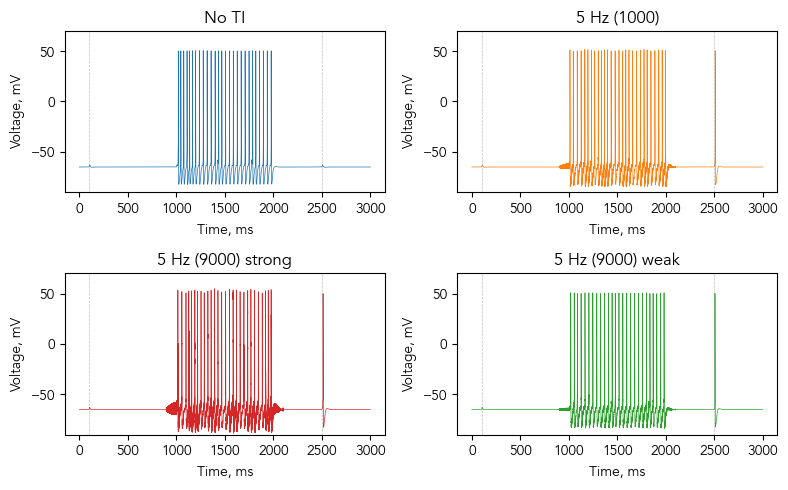

In [57]:
fig, axs = plt.subplots(nrows = 2, ncols = 2, figsize = (8, 2 * 2.5))
axs = axs.flatten()

for condition, ax in zip(conditions.keys(), axs):
    filename = conditions[condition]
    color = colors[condition]

    voltage = pd.read_csv(f"output/temporal-interference/{idx}/{filename}/voltage.csv")

    ax.plot(
        voltage.Time,
        voltage.Voltage,
        linewidth = 0.5,
        color = color
    )

    ax.set_xlabel("Time, ms")
    ax.set_ylabel("Voltage, mV")
    ax.set_ylim(-90, 70)

    ax.set_title(condition)

    ax.axvline(test_stimulus_1, linewidth = 0.5, color = "gray", linestyle = "--", alpha = 0.5)
    ax.axvline(test_stimulus_2, linewidth = 0.5, color = "gray", linestyle = "--", alpha = 0.5)

fig.tight_layout()
plt.show()

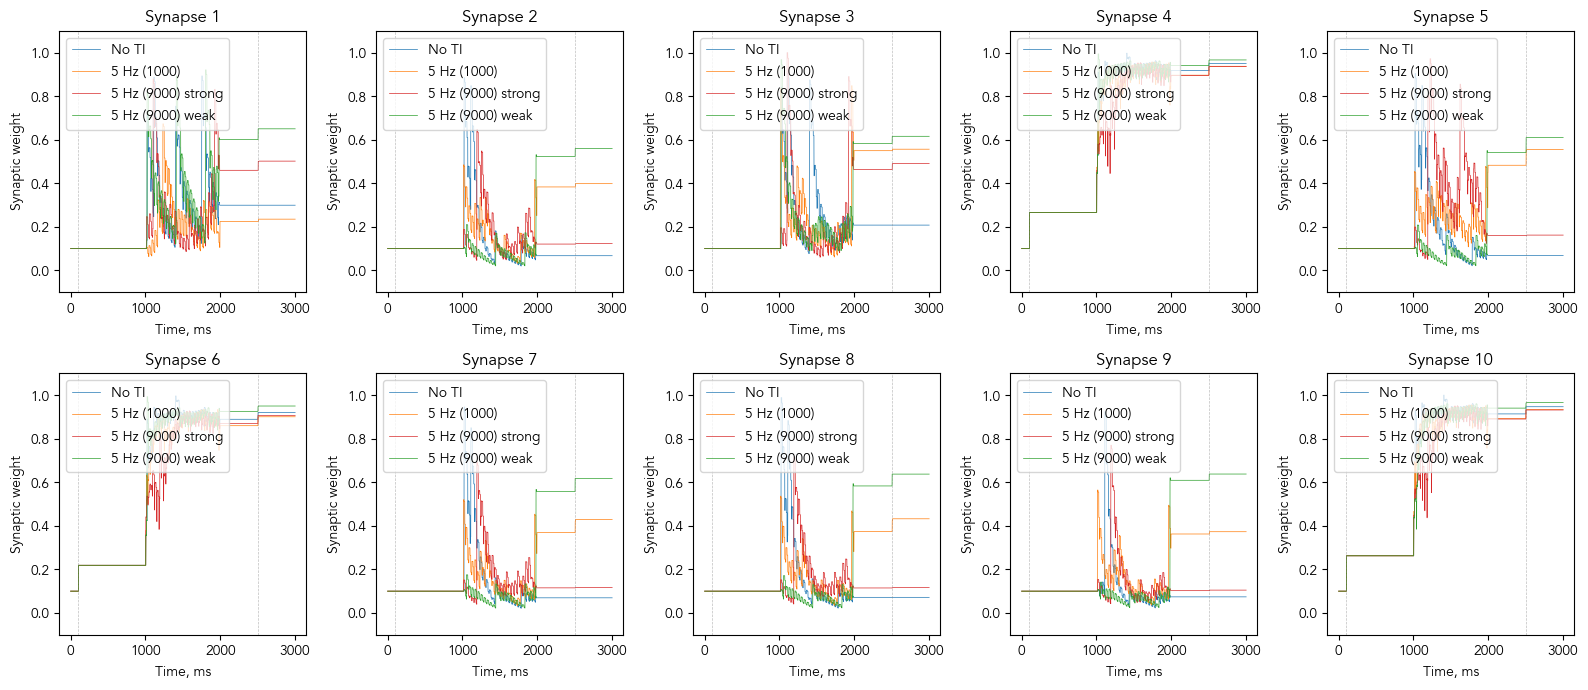

In [58]:
fig, axs = plt.subplots(nrows = 2, ncols = 5, figsize = (16, 2 * 3.5))
axs = axs.flatten()

synapses = [ f"Synapse{i}" for i in range(10) ]

for condition in conditions.keys():
    filename = conditions[condition]
    color = colors[condition]

    weights = pd.read_csv(f"output/temporal-interference/{idx}/{filename}/synapse_weights.csv", index_col = 0)

    for synapse, ax in zip(synapses, axs):
        ax.plot(
            weights.Time,
            weights[synapse],
            linewidth = 0.5,
            color = color,
            label = condition
        )

for i, ax in enumerate(axs):
    ax.set_xlabel("Time, ms")
    ax.set_ylabel("Synaptic weight")
    ax.set_ylim(-0.1, 1.1)
    ax.set_title(f"Synapse {i + 1}")
    ax.legend(loc = "upper left")
    ax.axvline(test_stimulus_1, linewidth = 0.5, color = "gray", linestyle = "--", alpha = 0.5)
    ax.axvline(test_stimulus_2, linewidth = 0.5, color = "gray", linestyle = "--", alpha = 0.5)

fig.tight_layout()
plt.show()

In [48]:
def expand_time(original, max_time = 10_000):
    original["Time"] = (original["Time"] / 0.025).round() * 0.025
    original = original.sort_values("Time")

    new_time = np.arange(0, max_time + 0.025, 0.025)

    expanded = pd.DataFrame({ "Time": new_time })
    expanded = pd.merge_asof(expanded, original, on = "Time", direction = "backward")

    return expanded

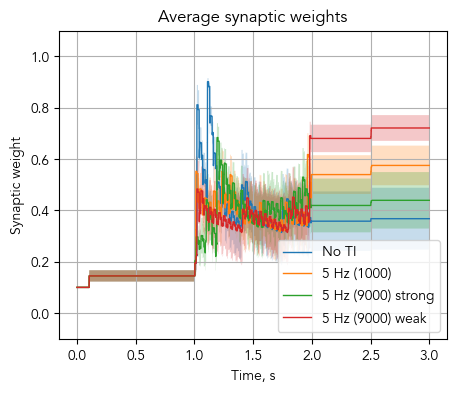

In [49]:
plt.figure(figsize = (5, 4))

for condition in conditions.keys():
    filename = conditions[condition]
    color = colors[condition]

    weights = []
    time = []

    synapse_weights = pd.read_csv(f"output/temporal-interference/{idx}/{filename}/synapse_weights.csv")
    synapse_weights = expand_time(synapse_weights, max_time = 3_000)
    time = synapse_weights.Time / 1000

    synapse_weights = np.array([ synapse_weights[f"Synapse{i}"] for i in range(0, 10) ])
    weights.append(synapse_weights)

    weights = np.concatenate(weights)

    mean = weights.mean(axis = 0)
    error = weights.std(axis = 0)  / np.sqrt(weights.shape[0])

    plt.plot(
        time,
        mean,
        linewidth = 1,
        label = condition
    )
    plt.fill_between(
        time, mean - error, mean + error,
        alpha = 0.25
    )

    plt.xlabel("Time, s")
    plt.ylabel("Synaptic weight")
    plt.ylim(-0.1, 1.1)

    plt.title("Average synaptic weights")

plt.legend()
plt.grid(True)

fig.tight_layout()
plt.show()

## Multiple runs

In [50]:
idxs = np.arange(0, 20)

In [51]:
def plot_conditions(conds, ax, title = ""):
    global conditions
    
    for condition in conds:
        filename = conditions[condition]
        color = colors[condition]
    
        weights = []
        time = []
    
        for idx in idxs:
            try:
                synapse_weights = pd.read_csv(f"output/temporal-interference/{idx}/{filename}/synapse_weights.csv")
                synapse_weights = expand_time(synapse_weights, max_time = 3_000)
                time = synapse_weights.Time / 1000
    
                synapse_weights = np.array([ synapse_weights[f"Synapse{i}"] for i in range(0, 10) ])
                weights.append(synapse_weights)
            except:
                print(idx)
    
        weights = np.concatenate(weights)
    
        mean = weights.mean(axis = 0)
        error = weights.std(axis = 0)  / np.sqrt(weights.shape[0])
    
        ax.plot(
            time,
            mean,
            linewidth = 1,
            label = condition,
            color = color
        )
        ax.fill_between(
            time, mean - error, mean + error,
            alpha = 0.25,
            color = color
        )
    
    ax.set_xlabel("Time, s")
    ax.set_ylabel("Synaptic weight")
    ax.set_ylim(-0.1, 1.1)

    ax.set_title(title)

    ax.legend(loc = "upper left")
    ax.grid(True)

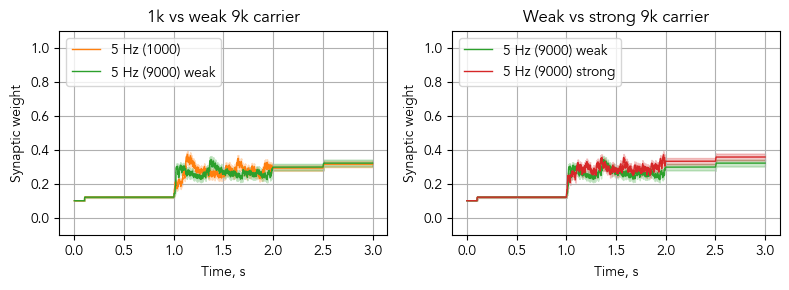

In [52]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (8, 3))

# plot_conditions(
#     conds = ["No TI", "5 Hz (1000)"],
#     ax = axs[0],
#     title = "No TI vs 5 Hz"
# )

plot_conditions(
    conds = ["5 Hz (1000)", "5 Hz (9000) weak"],
    ax = axs[0],
    title = "1k vs weak 9k carrier"
)

plot_conditions(
    conds = ["5 Hz (9000) weak", "5 Hz (9000) strong"],
    ax = axs[1],
    title = "Weak vs strong 9k carrier"
)

fig.tight_layout()
plt.show()